# Atmosphere Rendering Experiments

This notebook is the working area for the final project. The immediate goal is to keep a minimal rendering loop and a simple atmosphere-like baseline so the shader implementation can be iterated on incrementally.

Planned milestones:
- Replace the placeholder emission-absorption volume with an analytic atmosphere density model
- Add optical depth integration along the view ray and light ray
- Add Rayleigh and Mie phase functions
- Sweep sun angle and scattering parameters for comparison renders


In [1]:
import open3d as o3d
import slangpy as spy
from pyglm import glm
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "from_asst3" / "asst3" / "src"))
for name in list(sys.modules):
    if name == "cs248a_renderer" or name.startswith("cs248a_renderer."):
        del sys.modules[name]
from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.scene import Scene
from cs248a_renderer.model.mesh import Mesh
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D
from cs248a_renderer.model.material import PhysicsBasedMaterial, MaterialField, BRDFType
from cs248a_renderer.model.lights import PointLight, DirectionalLight
from cs248a_renderer.renderer.core_renderer import Renderer

import inspect
print(inspect.getsourcefile(Renderer))
print(hasattr(Renderer, "clear_render_target"))
print(Renderer)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
/home/waynechu/Documents/Stanford/CS248A/final_project/from_asst3/asst3/src/cs248a_renderer/renderer/core_renderer.py
True
<class 'cs248a_renderer.renderer.core_renderer.Renderer'>


In [2]:
# Device and module setup.
device = setup_device([])
renderer_modules = RendererModules(device)


[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] Slang compiler warnings:
/home/waynechu/Documents/Stanford/CS248A/final_project/from_asst3/asst3/src/cs248a_renderer/slang_shaders/./texture/texture.slang(33): warning 41000: unreachable code detected
        return outV;
        ^~~~~~



In [3]:
# Output texture setup.
OUTPUT_IMG_SIZE = (512, 512)
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)

renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules,
)
renderer.sqrt_spp = 1


In [4]:
def tone_mapping(image_np, gamma=2.2, exposure_time=1.0):
    gamma_corrected = np.power(np.clip(image_np[:, :, :3] * exposure_time, 0.0, None), 1.0 / gamma)
    return np.clip(gamma_corrected, 0.0, 1.0)


def save_image(image_np, path, gamma=2.2, exposure_time=1.0):
    mapped = tone_mapping(image_np, gamma=gamma, exposure_time=exposure_time)
    image = Image.fromarray((mapped * 255).astype(np.uint8))
    image.save(path)


## Atmosphere Parameters

These parameters are intentionally kept in Python first so experiments are easy to iterate on. Some of them are placeholders for the eventual shader-side implementation.


In [5]:
params = {
    "planet_radius": 0.35,
    "atmosphere_radius": 0.50,
    "rayleigh_scale_height": 0.08,
    "mie_scale_height": 0.03,
    "beta_rayleigh": np.array([0.35, 0.55, 1.00], dtype=np.float32),
    "beta_mie": np.array([0.90, 0.85, 0.75], dtype=np.float32),
    "mie_g": 0.76,
    "sun_direction": np.array([0.0, 0.35, -1.0], dtype=np.float32),
    "sun_intensity": 3.0,
    "voxel_size": 0.01,
}

params["sun_direction"] = params["sun_direction"] / np.linalg.norm(params["sun_direction"])
params


{'planet_radius': 0.35,
 'atmosphere_radius': 0.5,
 'rayleigh_scale_height': 0.08,
 'mie_scale_height': 0.03,
 'beta_rayleigh': array([0.35, 0.55, 1.  ], dtype=float32),
 'beta_mie': array([0.9 , 0.85, 0.75], dtype=float32),
 'mie_g': 0.76,
 'sun_direction': array([ 0.       ,  0.3303504, -0.9438583], dtype=float32),
 'sun_intensity': 3.0,
 'voxel_size': 0.01}

## Baseline Volume Generator

This is a temporary CPU-side proxy for the future shader-side atmosphere model. It creates a spherical shell with exponential falloff and encodes a simple emission color so the existing volume renderer can already produce atmosphere-like gradients.

This is not the final physical model. It is only a scaffold for testing camera placement, volume bounds, and parameter sweeps before moving the real scattering computation into the shader.


In [6]:
def make_atmosphere_volume_grid(resolution=96, p=params):
    coords = np.linspace(-0.5, 0.5, resolution, dtype=np.float32)
    z, y, x = np.meshgrid(coords, coords, coords, indexing="ij")
    pos = np.stack([x, y, z], axis=-1)
    radius = np.linalg.norm(pos, axis=-1)

    planet_r = p["planet_radius"]
    atmosphere_r = p["atmosphere_radius"]
    shell_mask = (radius >= planet_r) & (radius <= atmosphere_r)

    height = np.clip(radius - planet_r, 0.0, None)
    rayleigh_density = np.exp(-height / max(p["rayleigh_scale_height"], 1e-6))
    mie_density = np.exp(-height / max(p["mie_scale_height"], 1e-6))

    density = 0.65 * rayleigh_density + 0.35 * mie_density
    density *= shell_mask.astype(np.float32)

    up = np.zeros_like(pos)
    safe_radius = np.maximum(radius[..., None], 1e-6)
    up = pos / safe_radius
    sun_dir = p["sun_direction"].reshape(1, 1, 1, 3)
    sun_amount = np.clip(np.sum(up * sun_dir, axis=-1), 0.0, 1.0)

    rayleigh_color = p["beta_rayleigh"] / max(np.max(p["beta_rayleigh"]), 1e-6)
    mie_color = p["beta_mie"] / max(np.max(p["beta_mie"]), 1e-6)
    base_color = 0.8 * rayleigh_color + 0.2 * mie_color

    sunset_tint = np.array([1.0, 0.45, 0.12], dtype=np.float32)
    rgb = density[..., None] * (
        base_color.reshape(1, 1, 1, 3) * (0.25 + 0.75 * sun_amount[..., None])
        + sunset_tint.reshape(1, 1, 1, 3) * np.power(sun_amount[..., None], 6.0) * 0.4
    ) * p["sun_intensity"]

    volume_rgba = np.zeros((resolution, resolution, resolution, 4), dtype=np.float32)
    volume_rgba[..., :3] = rgb.astype(np.float32)
    volume_rgba[..., 3] = np.clip(density, 0.0, 1.0).astype(np.float32)
    return volume_rgba


def make_atmosphere_volume(resolution=96, p=params):
    volume_data = make_atmosphere_volume_grid(resolution=resolution, p=p)
    voxel_size = p["voxel_size"]
    return DenseVolume(
        name="atmosphere_proxy",
        transform=Transform3D(
            position=glm.vec3(0.0, 0.0, 0.0),
            rotation=glm.angleAxis(glm.radians(0.0), glm.vec3(0.0, 1.0, 0.0)),
            scale=glm.vec3(1.0, 1.0, 1.0),
        ),
        data=volume_data,
        properties={
            "pivot": (0.5, 0.5, 0.5),
            "voxel_size": voxel_size,
        },
    )


## Scene Setup

Build a minimal test scene with a planet mesh, a visible sun proxy mesh, a directional light, and the atmosphere volume. This matches the same triangle-plus-light-plus-volume loading flow used in asst3.


In [7]:
def set_camera(scene, eye, target, fov=45.0):
    cam = scene.camera
    cam.transform.position = eye
    cam.transform.rotation = glm.quatLookAt(glm.normalize(target - eye), glm.vec3(0.0, 1.0, 0.0))
    cam.fov = fov
    return cam


def make_colored_sphere_mesh(name, radius, position, color, resolution=48, smoothness=0.0):
    sphere_o3d = o3d.geometry.TriangleMesh.create_sphere(radius=radius, resolution=resolution)
    sphere_o3d.compute_vertex_normals()
    sphere_o3d.paint_uniform_color(np.asarray(color, dtype=np.float64))
    mesh = Mesh(sphere_o3d, name=name)
    mesh.transform = Transform3D(
        position=position,
        rotation=glm.quat(1.0, 0.0, 0.0, 0.0),
        scale=glm.vec3(1.0, 1.0, 1.0),
    )
    mesh.material = PhysicsBasedMaterial(
        albedo=MaterialField(glm.vec3(*color)),
        smoothness=smoothness,
        brdf_type=BRDFType.LAMBERTIAN,
    )
    return mesh


def build_planet_scene(p=params, atmosphere_resolution=96, sun_distance=2.2):
    scene = Scene()
    set_camera(scene, glm.vec3(0.0, -0.15, 1.35), glm.vec3(0.0, -0.05, 0.0), fov=45.0)

    planet = make_colored_sphere_mesh(
        name="planet",
        radius=p["planet_radius"] * 0.97,
        position=glm.vec3(0.0, 0.0, 0.0),
        color=(0.10, 0.18, 0.28),
        resolution=56,
        smoothness=0.05,
    )
    scene.add_object(planet)

    sun_position = glm.vec3(*(-p["sun_direction"] * sun_distance))
    sun_proxy = make_colored_sphere_mesh(
        name="sun_proxy",
        radius=0.08,
        position=sun_position,
        color=(1.0, 0.92, 0.70),
        resolution=24,
        smoothness=0.0,
    )
    scene.add_object(sun_proxy)

    sun_light = DirectionalLight(
        name="sun_light",
        direction=glm.vec3(*p["sun_direction"]),
        color=glm.vec3(1.0, 0.97, 0.92),
        intensity=1.75,
    )
    scene.add_object(sun_light)

    atmosphere = make_atmosphere_volume(resolution=atmosphere_resolution, p=p)
    return scene, atmosphere


scene, volume = build_planet_scene(params, atmosphere_resolution=96)


## Single View Render

Render the current scene using the existing triangle, light, and volume pipeline. The atmosphere is still the baseline emission-absorption proxy, but now it sits on top of an explicit scene.


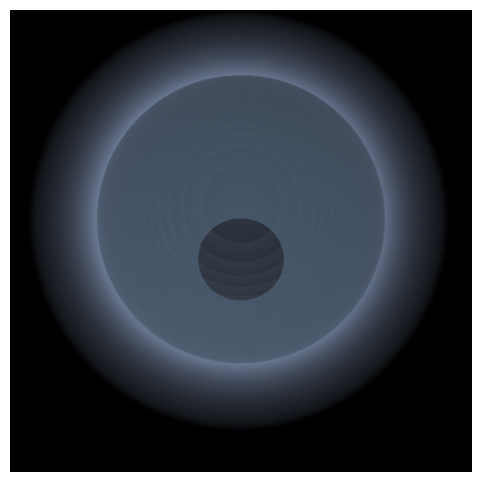

In [8]:
def render_scene(scene, volume, spp=1, exposure_time=0.8):
    renderer.load_triangles(scene=scene)
    renderer.load_lights(scene=scene)
    renderer.load_volume(volume=volume)

    if spp <= 1:
        renderer.render(
            scene.camera.view_matrix(),
            scene.camera.fov,
            smooth_shading=True,
            path_trace_depth=2,
        )
    else:
        renderer.clear_render_target()
        for _ in range(spp):
            renderer.render_step(
                scene.camera.view_matrix(),
                scene.camera.fov,
                smooth_shading=True,
                path_trace_depth=2,
            )

    return np.flipud(tone_mapping(output_image.to_numpy(), exposure_time=exposure_time))


preview_image = render_scene(scene, volume, spp=8, exposure_time=0.8)
plt.figure(figsize=(6, 6))
plt.imshow(preview_image)
plt.axis("off")
plt.show()


## Camera Sweep

Use this section to render the same scene from different camera angles, similar to the asst3 workflow where the scene stays fixed and only the camera moves.


In [9]:
def orbit_camera_position(distance, azimuth_deg, elevation_deg=10.0, target=glm.vec3(0.0, 0.0, 0.0)):
    azimuth = glm.radians(azimuth_deg)
    elevation = glm.radians(elevation_deg)
    x = distance * np.cos(elevation) * np.sin(azimuth)
    y = distance * np.sin(elevation)
    z = distance * np.cos(elevation) * np.cos(azimuth)
    return target + glm.vec3(float(x), float(y), float(z))


def render_with_camera_angles(azimuth_values, elevation_deg=10.0, distance=1.35, target=glm.vec3(0.0, 0.0, 0.0), spp=8):
    images = []
    for azimuth in azimuth_values:
        eye = orbit_camera_position(distance, azimuth, elevation_deg=elevation_deg, target=target)
        set_camera(scene, eye, target, fov=45.0)
        images.append(render_scene(scene, volume, spp=spp, exposure_time=0.8))
    return images


def render_with_sun_angle(y_values, resolution=96, spp=8):
    images = []
    for y in y_values:
        local_params = dict(params)
        sun_dir = np.array([0.0, y, -1.0], dtype=np.float32)
        sun_dir = sun_dir / np.linalg.norm(sun_dir)
        local_params["sun_direction"] = sun_dir
        local_scene, local_volume = build_planet_scene(local_params, atmosphere_resolution=resolution)
        images.append(render_scene(local_scene, local_volume, spp=spp, exposure_time=0.8))
    return images


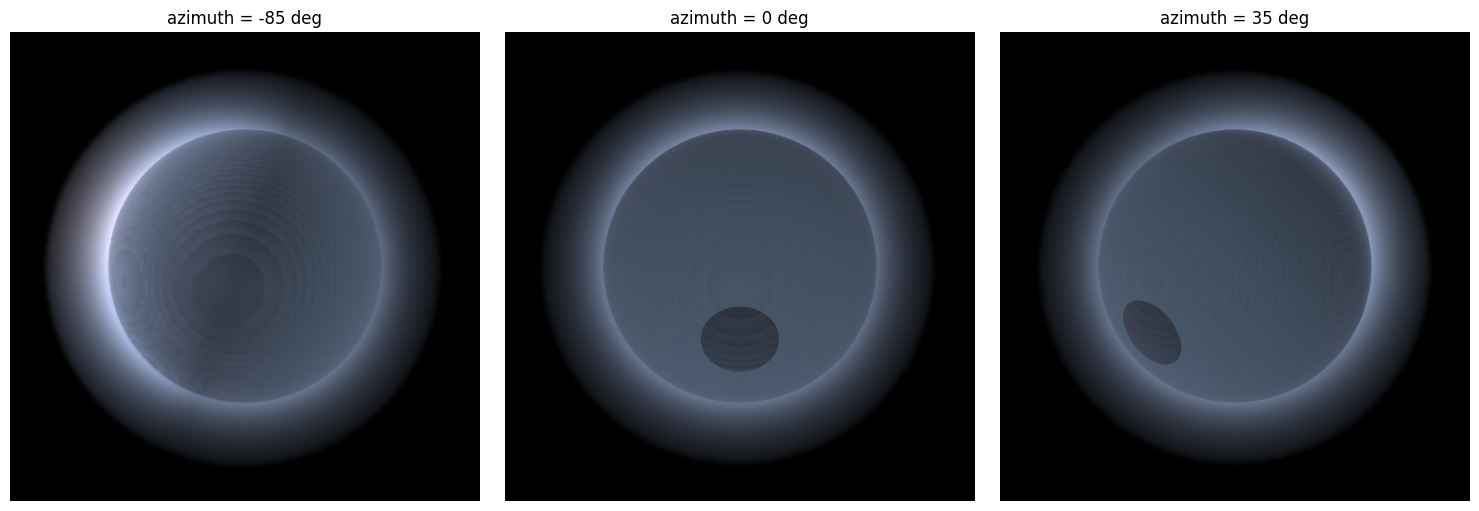

In [10]:
camera_azimuths = [-85.0, 0.0, 35.0]
images = render_with_camera_angles(camera_azimuths, elevation_deg=8.0, distance=1.45, spp=8)

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
if len(images) == 1:
    axes = [axes]

for ax, img, azimuth in zip(axes, images, camera_azimuths):
    ax.imshow(img)
    ax.set_title(f"azimuth = {azimuth:.0f} deg")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Next Shader Tasks

When moving beyond this baseline, the next changes should be made in the shader path rather than in this notebook:
- Replace the proxy RGB emission with physically motivated in-scattering
- Compute optical depth to the sun per sample point
- Separate Rayleigh and Mie densities and scattering coefficients
- Add phase functions and compare against this notebook's coarse proxy visuals
